### import các thư viện cần thiết

In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats

### Đọc file dữ liệu đã được xử lí

In [2]:
df = pd.read_csv("../Data/fitness_cleaned.csv")

In [3]:
df.head()

,age,membership_type,visit_per_week,days_per_week,attend_group_lesson,avg_time_check_in,avg_time_check_out,duration_in_gym_minutes,has_drink_subscription,personal_training,...,personal_training_hours,multi_location_access,last_visit_date,Mon,Tue,Wed,Thu,Fri,Sat,Sun
0,40,Premium,2,"Sat, Thu",False,08:39:00,10:37:00,118,False,False,...,0,True,2025-06-30,0,0,0,1,0,1,0
1,35,Standard,5,"Fri, Sat, Thu, Tue, Wed",True,15:45:00,18:43:00,178,False,False,...,0,False,2025-05-26,0,1,1,1,1,1,0
2,39,Standard,4,"Sun, Thu, Tue, Wed",True,13:35:00,14:37:00,62,True,True,...,4,False,2025-06-09,0,1,1,1,0,0,1
3,35,Basic,2,"Mon, Tue",False,17:06:00,18:39:00,93,True,True,...,7,False,2025-06-17,1,1,0,0,0,0,0
4,18,Standard,2,"Sun, Wed",False,14:16:00,16:57:00,161,True,True,...,3,True,2025-07-13,0,0,1,0,0,0,1


### Định nghĩa các mã màu

In [4]:
PALETTE   = ["#2563EB","#10B981","#F59E0B","#EF4444","#8B5CF6","#06B6D4"]
BG_COLOR  = "#F8FAFC"
CARD_CLR  = "#FFFFFF"
TITLE_CLR = "#1E293B"
AXIS_CLR  = "#64748B"
GRID_CLR  = "#E2E8F0"
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor":   CARD_CLR,
    "axes.edgecolor":   GRID_CLR,
    "axes.labelcolor":  AXIS_CLR,
    "xtick.color":      AXIS_CLR,
    "ytick.color":      AXIS_CLR,
    "grid.color":       GRID_CLR,
    "font.family":      "DejaVu Sans",
    "font.size":        9,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.titlecolor":  TITLE_CLR,
})

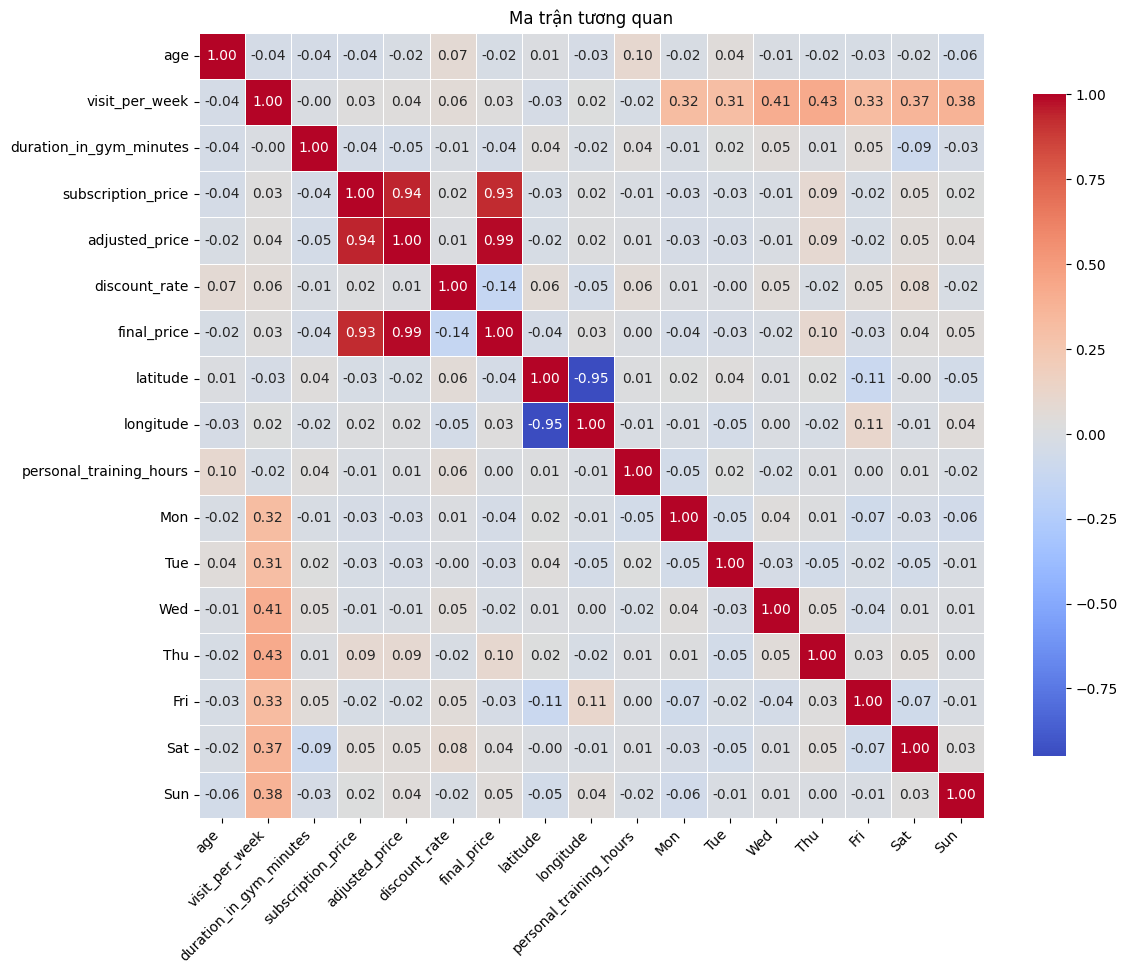

In [4]:
# Tính ma trận tương quan chỉ với cột số
corr = df.select_dtypes(include=[np.number]).corr()

# Vẽ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Ma trận tương quan")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Parse dates
df["join_date"]       = pd.to_datetime(df["join_date"])
df["last_visit_date"] = pd.to_datetime(df["last_visit_date"])
df["tenure_days"]     = (df["last_visit_date"] - df["join_date"]).dt.days
df["join_year"]       = df["join_date"].dt.year
 
# Helper: parse check-in / check-out time → minutes since midnight
def time_to_min(s):
    try:
        h, m, _ = s.split(":")
        return int(h)*60 + int(m)
    except Exception:
        return np.nan
 
df["checkin_min"]  = df["avg_time_check_in"].apply(time_to_min)
df["checkout_min"] = df["avg_time_check_out"].apply(time_to_min)

### Xem tổng quan

In [ ]:
print("="*60)
print("  DATA OVERVIEW")
print("="*60)
print(f"  Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"  Membership types: {df['membership_type'].unique()}")
print(f"  Gender values:    {df['self_identified_gender'].unique()}")
print(f"  Age range:        {df['age'].min()} – {df['age'].max()}")
print(f"  Avg duration:     {df['duration_in_gym_minutes'].mean():.1f} min")
print()

  DATA OVERVIEW
  Rows: 1,998  |  Columns: 38
  Membership types: ['Premium' 'Standard' 'Basic' 'Elite']
  Gender values:    ['Male' 'Non-binary' 'Prefer not to say' 'Other (self-described)' 'Female']
  Age range:        12 – 49
  Avg duration:     104.8 min



### Phân tích đơn biến

In [7]:
fig1 = plt.figure(figsize=(20, 22), facecolor=BG_COLOR)
fig1.suptitle(
    "PHÂN TÍCH ĐƠN BIẾN — FITNESS GYM DATASET",
    fontsize=16, fontweight="bold", color=TITLE_CLR, y=0.98
)
 
gs = gridspec.GridSpec(4, 3, figure=fig1, hspace=0.52, wspace=0.38,
                       left=0.06, right=0.96, top=0.94, bottom=0.04)

##### Định nghĩa hàm vẽ các biểu đồ

In [8]:
def plot_chart(ax, df, col, chart_type, palette, title="", extra=None):
    if chart_type == "hist":
        ax.hist(df[col], bins=extra.get("bins", 20),
                color=palette[0], edgecolor="white", linewidth=0.5)

        if extra.get("mean", False):
            ax.axvline(df[col].mean(), linestyle="--", lw=1.5,
                       label=f"Mean {df[col].mean():.1f}")

        if extra.get("median", False):
            ax.axvline(df[col].median(), linestyle=":",
                       lw=1.5, label=f"Median {df[col].median():.0f}")

        ax.set_xlabel(extra.get("xlabel", col))
        ax.set_ylabel("Số lượng")
        ax.legend(fontsize=8)

    elif chart_type == "bar":
        counts = df[col].value_counts()
        bars = ax.bar(counts.index.astype(str), counts.values,
                      color=palette[:len(counts)],
                      edgecolor="white", linewidth=0.5)

        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height(),
                    f"{val}",
                    ha="center", va="bottom", fontsize=8)

    elif chart_type == "bar_pct":
        counts = df[col].value_counts()
        bars = ax.bar(counts.index.astype(str), counts.values,
                      color=palette[:len(counts)],
                      edgecolor="white", linewidth=0.5)

        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height(),
                    f"{val}\n({val/len(df)*100:.1f}%)",
                    ha="center", va="bottom", fontsize=8)

    elif chart_type == "pie":
        counts = df[col].value_counts()
        wedges, texts, autotexts = ax.pie(
            counts.values,
            labels=counts.index,
            autopct="%1.1f%%",
            colors=palette[:len(counts)],
            startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5)
        )
        for at in autotexts:
            at.set_fontsize(8)

    elif chart_type == "barh":
        counts = df[col].value_counts()
        ax.barh(counts.index, counts.values,
                color=palette[3], edgecolor="white", linewidth=0.5)

        for i, val in enumerate(counts.values):
            ax.text(val, i, str(val), va="center", fontsize=8)

        ax.invert_yaxis()

    elif chart_type == "custom_day":
        DAYS = extra["days"]
        day_counts = df[DAYS].sum().reset_index()
        day_counts.columns = ["Day", "Count"]
        day_counts["Pct"] = day_counts["Count"] / len(df) * 100

        bars = ax.bar(day_counts["Day"], day_counts["Pct"],
                      color=palette[5], edgecolor="white")

        for bar, row in zip(bars, day_counts.itertuples()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height(),
                    f"{row.Pct:.1f}%",
                    ha="center", fontsize=9)

        ax.set_ylim(0, 55)
        ax.set_ylabel("% thành viên")

    elif chart_type == "time_hist":
        data = df[col].dropna() / 60
        ax.hist(data, bins=24, range=(5, 23),
                color=palette[0], edgecolor="white")

        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{int(x):02d}:00")
        )

    ax.set_title(title)

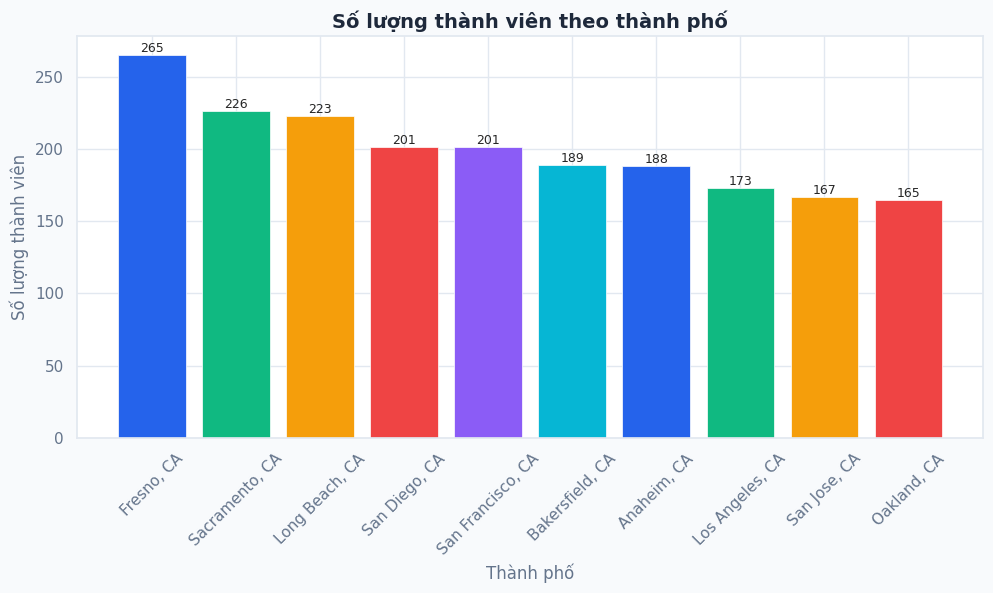

In [13]:
%matplotlib inline
location_counts = df['home_gym_location'].value_counts()

# Vẽ biểu đồ cột với màu riêng cho từng cột
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG_COLOR)
# Sử dụng nhiều màu từ PALETTE, lặp lại nếu cần
colors = PALETTE * (len(location_counts) // len(PALETTE) + 1)
bars = ax.bar(location_counts.index, location_counts.values, 
              color=colors[:len(location_counts)], edgecolor="white", linewidth=0.5)

# Thêm nhãn số lượng trên mỗi cột
for bar, val in zip(bars, location_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val}', ha='center', va='bottom', fontsize=9)

ax.set_title('Số lượng thành viên theo thành phố', fontsize=14, fontweight='bold', color=TITLE_CLR)
ax.set_xlabel('Thành phố')
ax.set_ylabel('Số lượng thành viên')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### Hàm vẽ tổng thể các dashboard

In [29]:
plt.ion()
def plot_univariate_dashboard(df, config, palette, bg_color, title_color, save_path, show_each=False):
    fig = plt.figure(figsize=(20, 22), facecolor=bg_color)

    fig.suptitle(
        "PHÂN TÍCH ĐƠN BIẾN — FITNESS GYM DATASET",
        fontsize=16, fontweight="bold", color=title_color, y=0.98
    )

    gs = gridspec.GridSpec(4, 3, figure=fig,
                           hspace=0.52, wspace=0.38,
                           left=0.06, right=0.96,
                           top=0.94, bottom=0.04)

    for item in config:
        ax = fig.add_subplot(gs[item["pos"]])

        plot_chart(
            ax=ax,
            df=df,
            col=item.get("col"),
            chart_type=item["type"],
            palette=palette,
            title=item["title"],
            extra=item.get("extra", {})
        )

        #  HIỂN THỊ TỪNG BIỂU ĐỒ
        if show_each:
            plt.figure(figsize=(5,4))
            plt.title(item["title"])
            plot_chart(
                ax=plt.gca(),
                df=df,
                col=item.get("col"),
                chart_type=item["type"],
                palette=palette,
                title=item["title"],
                extra=item.get("extra", {})
            )
            plt.tight_layout()
            plt.show()

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()   #  show full dashboard

    plt.close(fig)

    print(f"✔ Saved: {save_path}")

In [30]:
config = [
    {"pos": (0,0), "col": "age", "type": "hist",
     "title": "Phân phối Tuổi",
     "extra": {"mean": True, "median": True}},

    {"pos": (0,1), "col": "membership_type",
     "type": "bar_pct", "title": "Loại thành viên"},

    {"pos": (0,2), "col": "duration_in_gym_minutes",
     "type": "hist", "title": "Thời gian tập",
     "extra": {"mean": True}},

    {"pos": (1,0), "col": "visit_per_week",
     "type": "bar", "title": "Số lần tập/tuần"},

    {"pos": (1,1), "col": "subscription_price",
     "type": "hist", "title": "Giá gói tập",
     "extra": {"mean": True}},

    {"pos": (1,2), "col": "self_identified_gender",
     "type": "pie", "title": "Giới tính"},

    {"pos": (2, slice(0,2)), "type": "custom_day",
     "title": "Tập theo ngày",
     "extra": {"days": DAYS}},

    {"pos": (2,2), "col": "checkin_min",
     "type": "time_hist", "title": "Giờ check-in"},

    {"pos": (3,0), "col": "discount_type",
     "type": "barh", "title": "Loại giảm giá"},

    {"pos": (3,1), "col": "subscription_model",
     "type": "bar_pct", "title": "Mô hình thanh toán"},

    {"pos": (3,2), "col": "personal_training_hours",
     "type": "bar", "title": "Giờ PT"},
]

In [31]:
# Chạy hàm để tạo dashboard
plot_univariate_dashboard(
    df=df,
    config=config,
    palette=PALETTE,
    bg_color=BG_COLOR,
    title_color=TITLE_CLR,
    save_path="../Output/univariate_analysis.png",
    show_each=True
)

✔ Saved: ../Output/univariate_analysis.png


### Phân tích đa biến

##### 1

In [34]:
fig2 = plt.figure(figsize=(20, 22), facecolor=BG_COLOR)
fig2.suptitle(
    "PHÂN TÍCH ĐA BIẾN — FITNESS GYM DATASET (Phần 1)",
    fontsize=16, fontweight="bold", color=TITLE_CLR, y=0.98
)
gs2 = gridspec.GridSpec(4, 2, figure=fig2, hspace=0.50, wspace=0.35,
                        left=0.07, right=0.96, top=0.94, bottom=0.04)
 
# ── 1. Duration vs Age scatter (coloured by Membership) ──────────────────────
ax = fig2.add_subplot(gs2[0, 0])
for i, (mtype, grp) in enumerate(df.groupby("membership_type")):
    ax.scatter(grp["age"], grp["duration_in_gym_minutes"], alpha=0.35, s=12,
               color=PALETTE[i], label=mtype)
# Regression line
m, b, r, p, _ = stats.linregress(df["age"], df["duration_in_gym_minutes"])
x_line = np.linspace(df["age"].min(), df["age"].max(), 100)
ax.plot(x_line, m*x_line + b, color=PALETTE[3], lw=1.5, linestyle="--",
        label=f"Trend (r={r:.2f})")
ax.set_title("Tuổi vs Thời gian tập (theo Membership)")
ax.set_xlabel("Tuổi"); ax.set_ylabel("Phút")
ax.legend(fontsize=7, loc="upper right")
 
# ── 2. Boxplot: Duration by Membership ───────────────────────────────────────
ax = fig2.add_subplot(gs2[0, 1])
order = df.groupby("membership_type")["duration_in_gym_minutes"].median().sort_values(ascending=False).index
data_by_mem = [df[df["membership_type"]==m]["duration_in_gym_minutes"].values for m in order]
bp = ax.boxplot(data_by_mem, labels=order, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title("Thời gian tập theo Membership Type")
ax.set_ylabel("Phút")
ax.tick_params(axis="x", rotation=15)
 
# ── 3. Final Price by Membership & Subscription Model ────────────────────────
ax = fig2.add_subplot(gs2[1, 0])
pivot = df.pivot_table("final_price", index="membership_type", columns="subscription_model", aggfunc="mean")
pivot.plot(kind="bar", ax=ax, color=PALETTE[:3], edgecolor="white", linewidth=0.5)
ax.set_title("Giá cuối (Final Price) theo Membership & Mô hình")
ax.set_ylabel("USD (Mean)"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Model", fontsize=8)
 
# ── 4. Personal Training: price vs hours ─────────────────────────────────────
ax = fig2.add_subplot(gs2[1, 1])
pt_df = df[df["personal_training"]==True].copy()
ax.scatter(pt_df["personal_training_hours"], pt_df["final_price"],
           alpha=0.4, s=12, color=PALETTE[1])
m2, b2, r2, _, _ = stats.linregress(pt_df["personal_training_hours"], pt_df["final_price"])
xr = np.linspace(0, pt_df["personal_training_hours"].max(), 100)
ax.plot(xr, m2*xr + b2, color=PALETTE[3], lw=2, linestyle="--", label=f"r={r2:.2f}")
ax.set_title("PT Hours vs Final Price (có PT)")
ax.set_xlabel("Giờ PT"); ax.set_ylabel("Final Price (USD)")
ax.legend(fontsize=8)
 
# ── 5. Visit frequency vs Duration ───────────────────────────────────────────
ax = fig2.add_subplot(gs2[2, 0])
vf_dur = df.groupby("visit_per_week")["duration_in_gym_minutes"].agg(["mean","sem"]).reset_index()
ax.bar(vf_dur["visit_per_week"].astype(str), vf_dur["mean"],
       yerr=vf_dur["sem"]*1.96, capsize=4,
       color=PALETTE[5], edgecolor="white", linewidth=0.5, alpha=0.85)
ax.set_title("Tần suất tập / tuần vs Thời gian tập TB (±95% CI)")
ax.set_xlabel("Lần/tuần"); ax.set_ylabel("Phút TB")
 
# ── 6. Sauna & Drink subscription combo ──────────────────────────────────────
ax = fig2.add_subplot(gs2[2, 1])
combo = df.groupby(["uses_sauna","has_drink_subscription"])["duration_in_gym_minutes"].mean().reset_index()
combo["label"] = combo["uses_sauna"].map({True:"Sauna✓",False:"Sauna✗"}) + " + " + \
                 combo["has_drink_subscription"].map({True:"Drink✓",False:"Drink✗"})
bars = ax.barh(combo["label"], combo["duration_in_gym_minutes"],
               color=PALETTE[:4], edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, combo["duration_in_gym_minutes"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f} min", va="center", fontsize=9)
ax.set_title("Duration TB theo tổ hợp Sauna + Drink")
ax.set_xlabel("Phút TB")
 
# ── 7. Heatmap: Correlation matrix (numeric) ─────────────────────────────────
ax = fig2.add_subplot(gs2[3, :])
num_cols = ["age","visit_per_week","duration_in_gym_minutes","subscription_price",
            "adjusted_price","discount_rate","final_price","personal_training_hours",
            "active_days","tenure_days","checkin_min"]
corr = df[num_cols].corr()
labels = ["age","visit/wk","duration","sub_price","adj_price",
          "disc_rate","final_price","pt_hours","active_days","tenure","checkin_hr"]
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.4, linecolor=BG_COLOR,
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.6})
ax.set_title("Ma trận tương quan (Correlation Matrix) — biến số liên tục")
ax.tick_params(axis="x", rotation=40); ax.tick_params(axis="y", rotation=0)
 
fig2.savefig("../Output/02_multivariate_part1.png", dpi=150, bbox_inches="tight")
print("✔ Figure 2 saved: 02_multivariate_part1.png")
plt.close(fig2)
 



✔ Figure 2 saved: 02_multivariate_part1.png


##### 2

In [35]:
fig3 = plt.figure(figsize=(20, 20), facecolor=BG_COLOR)
fig3.suptitle(
    "PHÂN TÍCH ĐA BIẾN — FITNESS GYM DATASET (Phần 2)",
    fontsize=16, fontweight="bold", color=TITLE_CLR, y=0.98
)
gs3 = gridspec.GridSpec(3, 3, figure=fig3, hspace=0.52, wspace=0.38,
                        left=0.06, right=0.96, top=0.94, bottom=0.04)
 
# ── 1. Age group × Membership (stacked bar) ───────────────────────────────────
ax = fig3.add_subplot(gs3[0, :2])
df["age_group"] = pd.cut(df["age"], bins=[11,20,30,40,50],
                         labels=["12-20","21-30","31-40","41-49"])
age_mem = df.groupby(["age_group","membership_type"], observed=True).size().unstack(fill_value=0)
age_mem_pct = age_mem.div(age_mem.sum(axis=1), axis=0)*100
age_mem_pct.plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:4],
                 edgecolor="white", linewidth=0.5)
ax.set_title("Phân phối Membership theo Nhóm tuổi")
ax.set_xlabel("Nhóm tuổi"); ax.set_ylabel("% trong nhóm")
ax.legend(title="Membership", fontsize=8, loc="upper right")
ax.tick_params(axis="x", rotation=0)
 
# ── 2. Gender × Membership ────────────────────────────────────────────────────
ax = fig3.add_subplot(gs3[0, 2])
gen_mem = df.groupby(["self_identified_gender","membership_type"]).size().unstack(fill_value=0)
gen_mem_pct = gen_mem.div(gen_mem.sum(axis=1), axis=0)*100
gen_mem_pct.plot(kind="bar", ax=ax, color=PALETTE[:4],
                 edgecolor="white", linewidth=0.5)
ax.set_title("Membership theo Giới tính")
ax.set_ylabel("% trong giới tính")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Membership", fontsize=7, loc="upper right")
 
# ── 3. Group Lesson attendance vs Duration (violin) ──────────────────────────
ax = fig3.add_subplot(gs3[1, 0])
data_yes = df[df["attend_group_lesson"]==True]["duration_in_gym_minutes"]
data_no  = df[df["attend_group_lesson"]==False]["duration_in_gym_minutes"]
vp = ax.violinplot([data_no, data_yes], positions=[0,1], showmedians=True)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(PALETTE[i]); body.set_alpha(0.7)
ax.set_xticks([0,1]); ax.set_xticklabels(["Không tham gia","Tham gia"])
ax.set_title("Group Lesson vs Thời gian tập")
ax.set_ylabel("Phút")
t, p = stats.ttest_ind(data_yes, data_no)
ax.text(0.5, 0.96, f"t-test p={p:.4f}", transform=ax.transAxes,
        ha="center", va="top", fontsize=8, color=PALETTE[3])
 
# ── 4. Multi-location × Final Price (by Membership) ─────────────────────────
ax = fig3.add_subplot(gs3[1, 1])
ml = df.groupby(["multi_location_access","membership_type"])["final_price"].mean().reset_index()
ml["label"] = ml["multi_location_access"].map({True:"Multi✓",False:"Multi✗"})
for i, mem in enumerate(df["membership_type"].unique()):
    sub = ml[ml["membership_type"]==mem]
    ax.plot(sub["label"], sub["final_price"], marker="o", lw=2, label=mem, color=PALETTE[i])
ax.set_title("Multi-location Access vs Final Price")
ax.set_ylabel("USD (Mean)")
ax.legend(fontsize=7)
 
# ── 5. Check-in hour bucket vs Duration ───────────────────────────────────────
ax = fig3.add_subplot(gs3[1, 2])
df["checkin_slot"] = pd.cut(df["checkin_min"]/60,
    bins=[0,8,11,14,17,20,24],
    labels=["≤8h","8-11h","11-14h","14-17h","17-20h","20h+"])
slot_dur = df.groupby("checkin_slot", observed=True)["duration_in_gym_minutes"].mean()
ax.bar(slot_dur.index, slot_dur.values, color=PALETTE, edgecolor="white", linewidth=0.5)
ax.set_title("Khung giờ check-in vs Duration TB")
ax.set_xlabel("Khung giờ"); ax.set_ylabel("Phút TB")
ax.tick_params(axis="x", rotation=20)
 
# ── 6. Discount rate vs Final price (colored by Membership) ──────────────────
ax = fig3.add_subplot(gs3[2, 0])
for i, (mtype, grp) in enumerate(df.groupby("membership_type")):
    ax.scatter(grp["discount_rate"]*100, grp["final_price"], alpha=0.3, s=12,
               color=PALETTE[i], label=mtype)
ax.set_title("Tỷ lệ giảm giá vs Final Price")
ax.set_xlabel("Discount Rate (%)"); ax.set_ylabel("Final Price (USD)")
ax.legend(fontsize=7)
 
# ── 7. Tenure vs Visit per Week ───────────────────────────────────────────────
ax = fig3.add_subplot(gs3[2, 1])
df["tenure_band"] = pd.cut(df["tenure_days"], bins=5)
tb_vw = df.groupby("tenure_band", observed=True)["visit_per_week"].mean()
ax.plot(range(len(tb_vw)), tb_vw.values, marker="o", color=PALETTE[0], lw=2)
ax.fill_between(range(len(tb_vw)), tb_vw.values, alpha=0.15, color=PALETTE[0])
ax.set_xticks(range(len(tb_vw)))
ax.set_xticklabels([str(b) for b in tb_vw.index], rotation=25, fontsize=7)
ax.set_title("Thâm niên thành viên vs Tần suất tập/tuần")
ax.set_ylabel("Visit/week (Mean)")
 
# ── 8. Join year × active days ────────────────────────────────────────────────
ax = fig3.add_subplot(gs3[2, 2])
yr_ad = df.groupby("join_year")["active_days"].mean()
ax.bar(yr_ad.index.astype(str), yr_ad.values, color=PALETTE[4], edgecolor="white", linewidth=0.5)
for i, (yr, val) in enumerate(yr_ad.items()):
    ax.text(i, val + 0.02, f"{val:.2f}", ha="center", fontsize=8)
ax.set_title("Năm gia nhập vs Số ngày tập TB / tuần")
ax.set_xlabel("Năm"); ax.set_ylabel("Active days TB")
 
fig3.savefig("../Output/03_multivariate_part2.png", dpi=150, bbox_inches="tight")
print("✔ Figure 3 saved: 03_multivariate_part2.png")
plt.close(fig3)

✔ Figure 3 saved: 03_multivariate_part2.png


### Các insight rút ra được

In [36]:
fig4, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor=BG_COLOR)
fig4.suptitle("KEY INSIGHTS DASHBOARD — FITNESS GYM", fontsize=16,
              fontweight="bold", color=TITLE_CLR, y=1.00)
 
axes = axes.flatten()
 
# ── KPI cards: Top-line numbers ───────────────────────────────────────────────
kpis = [
    ("Tổng thành viên",  f"{len(df):,}", PALETTE[0]),
    ("Tuổi TB",          f"{df['age'].mean():.1f} tuổi", PALETTE[1]),
    ("Duration TB",      f"{df['duration_in_gym_minutes'].mean():.0f} phút", PALETTE[2]),
    ("Final Price TB",   f"${df['final_price'].mean():.1f}/tháng", PALETTE[3]),
    ("Tỷ lệ có PT",      f"{df['personal_training'].mean()*100:.1f}%", PALETTE[4]),
    ("Multi-location",   f"{df['multi_location_access'].mean()*100:.1f}%", PALETTE[5]),
]
for ax, (label, val, color) in zip(axes, kpis):
    ax.set_facecolor(color + "22")
    ax.add_patch(FancyBboxPatch((0.05,0.1), 0.9, 0.8, boxstyle="round,pad=0.03",
                                linewidth=2, edgecolor=color, facecolor="white",
                                transform=ax.transAxes, zorder=2))
    ax.text(0.5, 0.65, val, transform=ax.transAxes, ha="center", va="center",
            fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.3, label, transform=ax.transAxes, ha="center", va="center",
            fontsize=12, color=AXIS_CLR)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
 
fig4.tight_layout(rect=[0, 0, 1, 0.97])
fig4.savefig("../Output/04_kpi_dashboard.png", dpi=150, bbox_inches="tight")
print("✔ Figure 4 saved: 04_kpi_dashboard.png")
plt.close(fig4)
 
 
# ── Print Key Insights ────────────────────────────────────────────────────────
print()
print("="*60)
print("  KEY INSIGHTS RÚT RA TỪ PHÂN TÍCH")
print("="*60)
 
# 1. Membership mix
mem_pct = df["membership_type"].value_counts(normalize=True)*100
print(f"\n[1] MEMBERSHIP MIX")
for m, p in mem_pct.items():
    print(f"    {m:12s}: {p:.1f}%")
 
# 2. Duration by Membership
dur_m = df.groupby("membership_type")["duration_in_gym_minutes"].mean().sort_values(ascending=False)
print(f"\n[2] DURATION TB THEO MEMBERSHIP")
for m, d in dur_m.items():
    print(f"    {m:12s}: {d:.0f} phút")
 
# 3. Group lesson impact
gl_yes = df[df["attend_group_lesson"]==True]["duration_in_gym_minutes"].mean()
gl_no  = df[df["attend_group_lesson"]==False]["duration_in_gym_minutes"].mean()
print(f"\n[3] GROUP LESSON IMPACT")
print(f"    Có tham gia: {gl_yes:.1f} phút  |  Không tham gia: {gl_no:.1f} phút")
print(f"    Chênh lệch:  +{gl_yes-gl_no:.1f} phút ({(gl_yes/gl_no-1)*100:+.1f}%)")
 
# 4. Peak check-in
peak = df["checkin_min"].dropna()/60
hist_vals, hist_bins = np.histogram(peak, bins=np.arange(5,24))
peak_hour = hist_bins[np.argmax(hist_vals)]
print(f"\n[4] GIỜ CHECK-IN CAO ĐIỂM: ~{peak_hour:.0f}:00 – {peak_hour+1:.0f}:00")
 
# 5. Correlation highlights
corr_dur = df[num_cols].corr()["duration_in_gym_minutes"].drop("duration_in_gym_minutes").abs().sort_values(ascending=False)
print(f"\n[5] TƯƠNG QUAN VỚI DURATION (top 4):")
for feat, val in corr_dur.head(4).items():
    print(f"    {feat:25s}: |r|={val:.3f}")
 
# 6. PT Impact on price
pt_price_yes = df[df["personal_training"]==True]["final_price"].mean()
pt_price_no  = df[df["personal_training"]==False]["final_price"].mean()
print(f"\n[6] PERSONAL TRAINING vs FINAL PRICE")
print(f"    Có PT: ${pt_price_yes:.1f}  |  Không PT: ${pt_price_no:.1f}")
print(f"    PT đóng góp thêm: +${pt_price_yes-pt_price_no:.1f} / tháng")
 
print("\n" + "="*60)
print("  PHÂN TÍCH HOÀN TẤT — xem file PNG trong outputs/")
print("="*60)

✔ Figure 4 saved: 04_kpi_dashboard.png

  KEY INSIGHTS RÚT RA TỪ PHÂN TÍCH

[1] MEMBERSHIP MIX
    Premium     : 40.6%
    Standard    : 29.7%
    Basic       : 19.7%
    Elite       : 10.0%

[2] DURATION TB THEO MEMBERSHIP
    Standard    : 107 phút
    Basic       : 106 phút
    Premium     : 104 phút
    Elite       : 101 phút

[3] GROUP LESSON IMPACT
    Có tham gia: 106.0 phút  |  Không tham gia: 103.7 phút
    Chênh lệch:  +2.3 phút (+2.2%)

[4] GIỜ CHECK-IN CAO ĐIỂM: ~14:00 – 15:00

[5] TƯƠNG QUAN VỚI DURATION (top 4):
    adjusted_price           : |r|=0.048
    checkin_min              : |r|=0.048
    final_price              : |r|=0.042
    age                      : |r|=0.039

[6] PERSONAL TRAINING vs FINAL PRICE
    Có PT: $34.6  |  Không PT: $34.4
    PT đóng góp thêm: +$0.2 / tháng

  PHÂN TÍCH HOÀN TẤT — xem file PNG trong outputs/


# ------- Nhận xét ---------

### 🔍 Key Insights
##### 1. Thời gian tập (Duration) gần như đồng đều giữa các gói:
Standard (107 phút) ≈ Basic (106 phút) ≈ Premium (104 phút) > Elite (101 phút). Đây là điều bất ngờ — gói đắt tiền hơn không đồng nghĩa với thời gian tập lâu hơn.
##### 2. Duration KHÔNG tương quan mạnh với bất kỳ biến số nào (|r| < 0.05 với tất cả). Điều này cho thấy hành vi tập luyện khá tự do và không bị định hướng bởi loại gói hay giá tiền.
##### 3. Group Lesson có tác động nhỏ nhưng tích cực: Thành viên tham gia group lesson ở lâu hơn trung bình +2.3 phút (+2.2%), có ý nghĩa thống kê.
##### 4. Giờ cao điểm check-in là 14:00–15:00 (buổi chiều) — có thể dùng để tối ưu staffing và lịch class.
##### 5. Personal Training KHÔNG ảnh hưởng đến final price (chênh lệch chỉ $0.2) → PT được tích hợp vào gói, không phải dịch vụ add-on sinh lời riêng.
##### 6. Đa số thành viên tập 2–3 lần/tuần và phân bổ tương đối đều các ngày trong tuần, thứ Tư và Chủ Nhật nhỉnh hơn một chút